# Frequency reconstruction and spectral recovery, Pagani *et al.* figures

**PATCHALIAS.** This notebook produces **two figures and nothing else**, on the pure-sinusoid sweep
of Deliverable~1's Data section:

1. **Reconstruction**, input frequency against the dominant frequency the model actually generates,
   with the ideal diagonal. Where the curve leaves the diagonal, the model is rebuilding the wrong
   frequency.
2. **Spectral recovery map**, a green / yellow / red strip along the spectrum saying where the
   frequency is still readable from the model's representation and where it is not.

It is deliberately separate from `bayesian_analysis.ipynb` and self-contained: both figures are
built here from `probe_lib`, so nothing depends on the older notebooks in `chronos/testing/`.
Signals are **pure sinusoids** ($2$–$250$ Hz), which is the first analysis of Deliverable~1, the
generator backgrounds belong to the Bayesian part.

Outputs go next to the Bayesian run, in `_run/<mode>/figures/`.

## 0, Setup

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {"torch": "torch", "chronos": "chronos-forecasting",
            "sklearn": "scikit-learn", "pyarrow": "pyarrow"}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("nothing to install")

nothing to install


In [2]:
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/FedericoSabbadini/patchAliasing.git"
IN_COLAB = "google.colab" in sys.modules
MARKER = Path("chronos") / "bayesian" / "probe_lib.py"

def find_repo() -> Path:
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / MARKER).exists():
            return cand
    target = Path("/content/patchAliasing") if IN_COLAB else here / "patchAliasing"
    if not (target / MARKER).exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(target)])
    if not (target / MARKER).exists():
        raise FileNotFoundError(f"{MARKER} missing from {target}; push it or upload it by hand.")
    return target

REPO = find_repo()
sys.path.insert(0, str(REPO / "chronos" / "bayesian"))
print("repository:", REPO)

repository: C:\Users\feder\Desktop\patchAliasing


In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

warnings.filterwarnings("ignore")
import probe_lib as pl

SEED = pl.SEED
np.random.seed(SEED)

# ---- what to run ----------------------------------------------------------------------
# Every geometry of the sweep. (16, 16) is the official amazon/chronos-bolt-tiny, which is the
# model Deliverable 1's first analysis targets; the rest are the retrained variants. Set
# GEOMETRIES = [(16, 16)] to look at one only.
GEOMETRIES = pl.MODELS

SMOKE = False                      # True -> coarse grid, ~1 minute, for a pipeline check
FREQ_STEP   = 8 if SMOKE else 1    # sweep step [Hz]. 1 Hz is the grid Deliverable 1 specifies
                                   # for the sine set, and it makes DELTA_BINS=1 below mean a
                                   # +/-1 Hz local task -- the same separation the Bayesian
                                   # analysis probes in its frequency-local codelength, so the
                                   # two readings of "is this frequency readable" agree.
N_PHASE     = 2 if SMOKE else 6    # phases per frequency (non-redundant S_f sampling)
GEN_LEN     = 128 if SMOKE else 256   # autoregressive rollout length for figure 1
N_PHASE_GEN = 1 if SMOKE else 3    # phases per frequency for the rollout
BATCH       = 64

_root = REPO / "chronos" / "bayesian" / "_run"
OUT = _root / ("smoke" if SMOKE else "full") / "figures"
OUT.mkdir(parents=True, exist_ok=True)

FREQS = np.arange(pl.BAND[0], pl.BAND[1] + 1e-9, FREQ_STEP)
print(f"{'SMOKE' if SMOKE else 'FULL'} | {len(GEOMETRIES)} geometries | "
      f"{len(FREQS)} frequencies x up to {N_PHASE} phases")
print(f"figures -> {OUT}")

FULL | 5 geometries | 249 frequencies x up to 6 phases
figures -> C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\figures


## 1, Measurement

Two quantities per geometry, both on pure sinusoids.

**Reconstruction.** The model is given a sinusoid, its median forecast is fed back into the context,
and the rollout continues to `GEN_LEN` samples. The **dominant** frequency of the output is read off
as `argmax |DFT|` and compared with the frequency that went in. On the diagonal the tone survives;
a flat segment means a range of inputs collapses onto one output, and a jump means the model
rebuilds a tone that was never there.

**Spectral recovery.** A linear probe is trained on the $256$-d $[\mathrm{REG}]$ vector at the
projected head, where the paper localises the compression drop, and its cross-validated accuracy
is mapped along the spectrum. This asks something more basic than the rollout: is the frequency
still *present* in the representation, whatever the forecast then does with it?

Two probing tasks are computed. The **seven band tasks** are the paper's, each asking whether a tone
falls in the lower or upper half of its band; they carry a known artefact, since a task is genuinely
ambiguous *at its own decision boundary*, which is why the project's earlier testing notebook
dropped this figure. The **local discrimination** task has no such artefact: at each frequency it
asks one question of constant difficulty, can the probe separate $f-\Delta$ from $f+\Delta$?, so
every column is comparable. That is the row to trust, and the one used for the cross-model
comparison.

In [4]:
STAGE = "output_head"          # the paper's h4: the projected quantile head
DELTA_BINS = 1                 # local task compares neighbours, so delta = DELTA_BINS * FREQ_STEP

def probe_accuracy(X, y, seed=SEED):
    """Cross-validated per-example correctness of a linear probe."""
    if len(np.unique(y)) < 2:
        return None
    n_splits = int(min(5, np.bincount(y).min()))
    if n_splits < 2:
        return None
    n_comp = max(2, min(20, X.shape[1], len(y) - len(y) // n_splits - 1))
    clf = make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                        LogisticRegression(max_iter=2000))
    yhat = cross_val_predict(clf, X, y, cv=StratifiedKFold(n_splits, shuffle=True,
                                                           random_state=seed))
    return (yhat == y).astype(float)


def rollout_dominant(probe, freqs, n_phase):
    """Dominant output frequency after an autoregressive rollout, averaged over phases.

    All (frequency, phase) pairs advance in lockstep, so each rollout step is one batched forward
    pass rather than one per signal.
    """
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, pl.CTX) for f, ph in items])   # pure sinusoids
    gen = np.zeros((len(items), 0), dtype=np.float32)
    while gen.shape[1] < GEN_LEN:
        step = probe.forecast(ctx)
        gen = np.concatenate([gen, step], axis=1)
        ctx = np.concatenate([ctx, step], axis=1)[:, -pl.CTX:]                   # slide the window
    gen = gen[:, :GEN_LEN]
    x = gen - gen.mean(axis=1, keepdims=True)
    mag = np.abs(np.fft.rfft(x, axis=1))
    fr = np.fft.rfftfreq(GEN_LEN, d=1 / pl.FS)
    dom = fr[np.argmax(mag[:, 1:], axis=1) + 1]                                  # skip the DC bin
    out = pd.DataFrame(items, columns=["freq", "phase"])
    out["dominant"] = dom
    return out.groupby("freq")["dominant"].agg(["mean", "std"]).reset_index()


def spectral_accuracy(probe, freqs, n_phase):
    """Per-frequency probe accuracy: the seven band tasks, plus the local f+/-delta task."""
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, pl.CTX) for f, ph in items])
    feats = probe.capture_reg(ctx)[STAGE]
    lab_f = np.array([f for f, _ in items])

    rows, labels = [], []
    for (name, lo, hi, bnd) in pl.BAND_TASKS:
        m = (lab_f >= lo) & (lab_f <= hi)
        ok = probe_accuracy(feats[m], (lab_f[m] > bnd).astype(int))
        a = np.full(len(freqs), np.nan)
        if ok is not None:
            fm = lab_f[m]
            for ci, f in enumerate(freqs):
                sel = fm == f
                if sel.any():
                    a[ci] = ok[sel].mean()
        rows.append(a); labels.append(f"band task {name}")

    local = np.full(len(freqs), np.nan)
    for ci in range(DELTA_BINS, len(freqs) - DELTA_BINS):
        m = np.isin(lab_f, [freqs[ci - DELTA_BINS], freqs[ci + DELTA_BINS]])
        ok = probe_accuracy(feats[m], (lab_f[m] == freqs[ci + DELTA_BINS]).astype(int))
        if ok is not None:
            local[ci] = ok.mean()
    rows.append(local); labels.append(f"local $f\\pm{DELTA_BINS*FREQ_STEP:g}$ Hz")
    return np.vstack(rows), labels

In [5]:
# One geometry at a time: load, measure, free. Chronos-Bolt-tiny is small, but Colab runtimes are
# not, and holding five pipelines at once buys nothing here.
RESULTS = {}
for (P, S) in GEOMETRIES:
    probe = pl.Probe(P, S, device="cpu", batch_size=BATCH)
    print(f"\n=== {probe.label}  (P={probe.P}, S={probe.S}) ===", flush=True)
    try:
        recon = rollout_dominant(probe, FREQS, N_PHASE_GEN)
        acc, row_labels = spectral_accuracy(probe, FREQS, N_PHASE)
        RESULTS[probe.tag] = dict(P=probe.P, S=probe.S, label=probe.label,
                                  recon=recon, acc=acc, row_labels=row_labels)
        rmse = float(np.sqrt(np.mean((recon["mean"] - recon["freq"]) ** 2)))
        good = np.nanmean(acc[-1] >= 0.9) * 100
        print(f"    spectral RMSE {rmse:6.1f} Hz | local task: {good:.0f}% of the band recovered")
    finally:
        probe.close()

# archive the numbers next to the figures
for tag, r in RESULTS.items():
    r["recon"].to_parquet(OUT.parent / f"recon_{tag}.parquet", index=False)
    pd.DataFrame(r["acc"].T, columns=r["row_labels"], index=FREQS).rename_axis("freq_hz") \
      .to_parquet(OUT.parent / f"spectral_accuracy_{tag}.parquet")
print(f"\nmeasured {len(RESULTS)} geometries")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 11221.55it/s]


=== p16-s8 (local p16-s8-seed42)  (P=16, S=8) ===


    spectral RMSE  132.8 Hz | local task: 56% of the band recovered


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

    spectral RMSE  131.0 Hz | local task: 38% of the band recovered


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 5136.40it/s]


=== p16-s16 (local p16-s16-seed42)  (P=16, S=16) ===


    spectral RMSE  132.6 Hz | local task: 45% of the band recovered

measured 5 geometries


## 2, Per-geometry figures

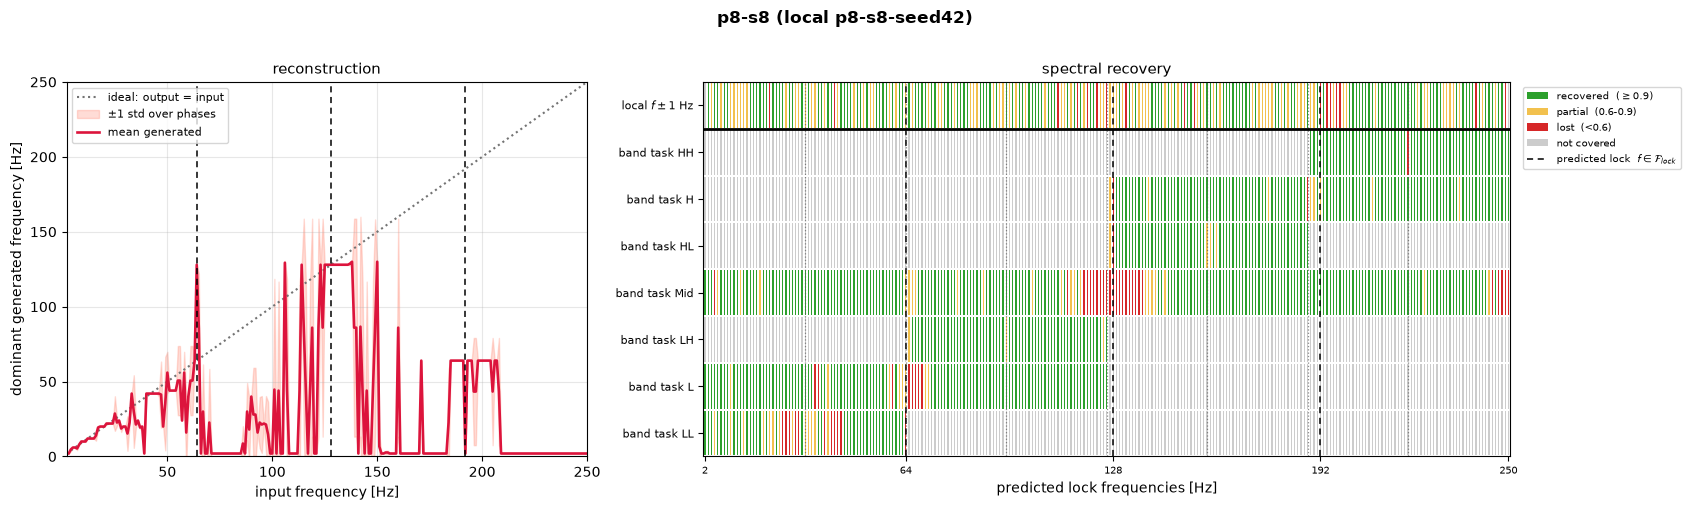

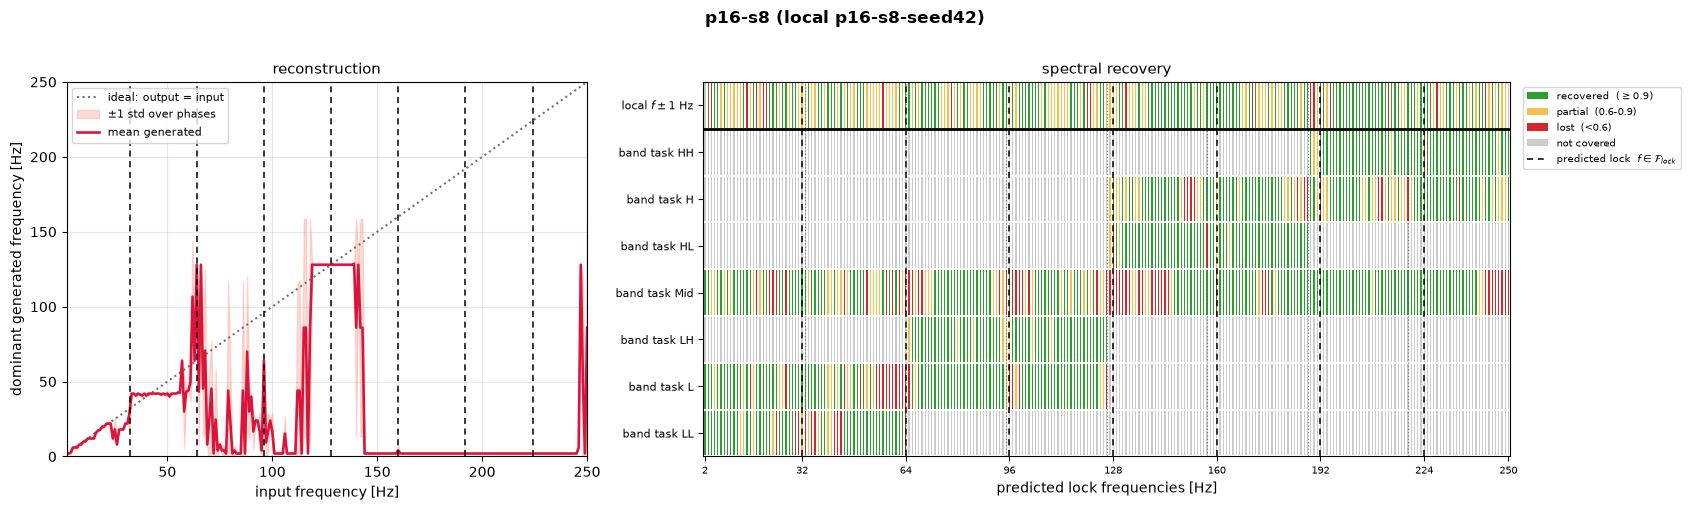

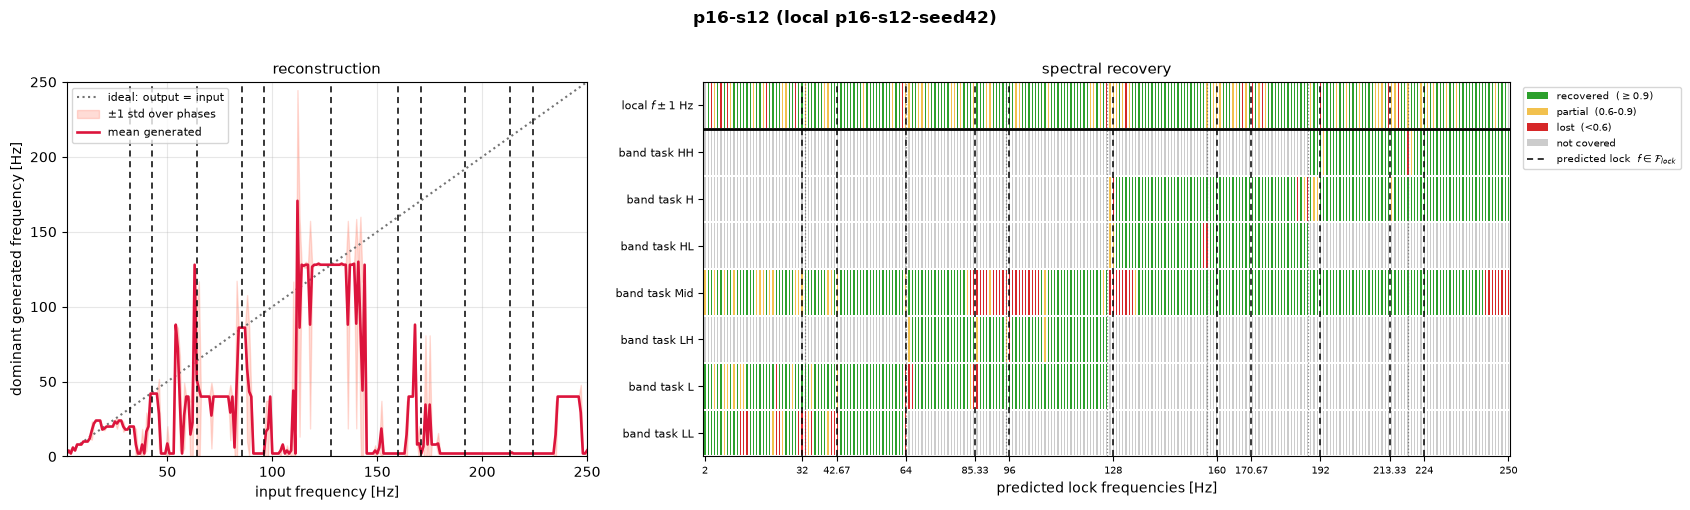

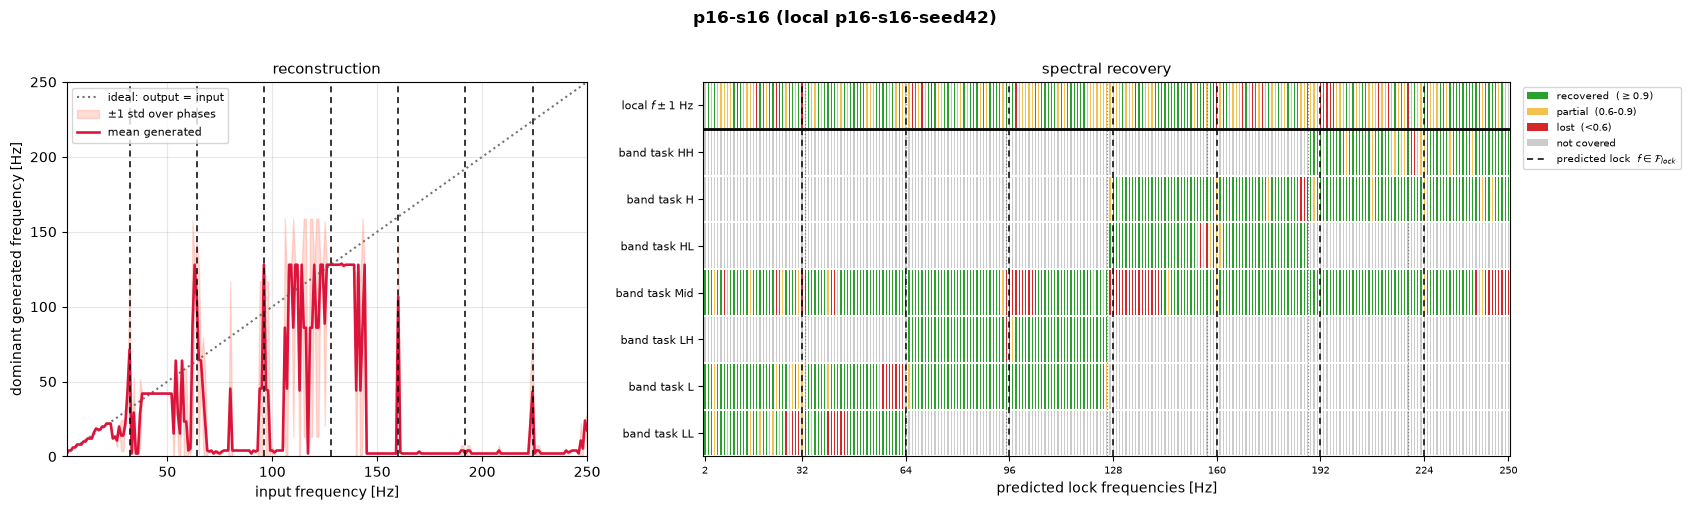

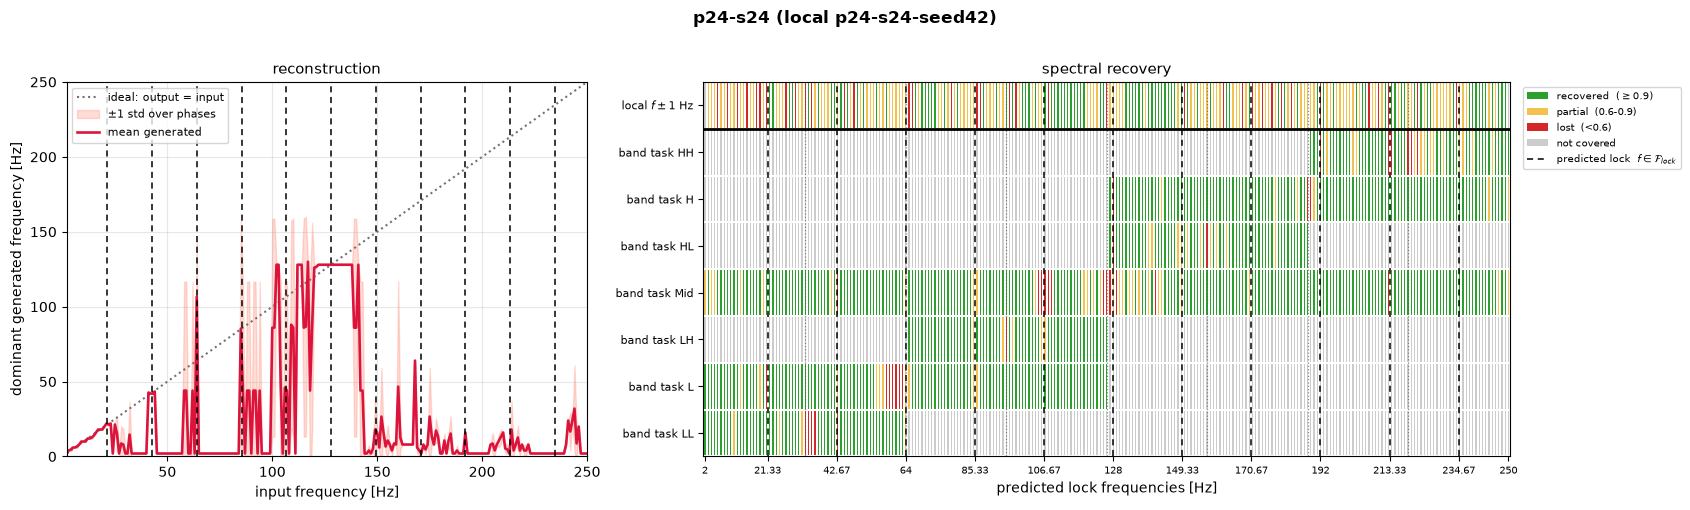

In [6]:
import matplotlib.patheffects as pe

CMAP = ListedColormap(["#cccccc", "#d62728", "#f2c14e", "#2ca02c"])
NORM = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], CMAP.N)

# Lock markers have to read on top of red, yellow and green cells alike, so they are drawn as
# high-contrast lines with a white halo rather than as thin coloured rules.
HALO = [pe.Stroke(linewidth=5.0, foreground="white"), pe.Normal()]
# One marker for the whole locked class F_lock, rather than one per family: the two coincide on
# every P=S geometry, and separating them added a distinction the figure does not need to make.
C_LOCK = "#000000"                            # black
DASH_LOCK = (0, (4, 3))                       # dashed, fine
LINE_OVER_TOP = 0.22          # the markers run past the top of the band, where nothing else is
LINE_OVER_BOT = 0.0           # and NOT past the bottom, where the tick labels are

def lock_frequencies(geometries):
    """Every predicted site of every geometry, so all panels share one set of ticks."""
    v = set()
    for (P, S) in geometries:
        v |= {round(f, 2) for f in pl.patch_nulls(P)}
        v |= {round(f, 2) for f in pl.stride_locks(S)}
    return sorted(v)

LOCK_TICKS = lock_frequencies(GEOMETRIES)

def band_edges(freqs, gap=6.0):
    """Add the first and last swept frequency to a tick list, so every axis states its own range.

    A lock sitting within `gap` Hz of an edge is dropped in favour of the edge itself, which would
    otherwise print two labels on top of one another.
    """
    lo, hi = float(FREQS[0]), float(FREQS[-1])
    keep = [f for f in freqs if abs(f - lo) > gap and abs(f - hi) > gap]
    return sorted({lo, hi} | set(keep))

def own_locks(P, S):
    """The predicted sites of ONE geometry: what that panel's axis should be ticked with."""
    return sorted({round(f, 2) for f in pl.patch_nulls(P)} |
                  {round(f, 2) for f in pl.stride_locks(S)})

def label_lock_axis(ax, freqs, to_pos, rotation=0, fontsize=7):
    """Tick the frequency axis at given lock frequencies instead of round numbers."""
    ax.set_xticks([to_pos(f) for f in freqs])
    ax.set_xticklabels([f"{f:g}" for f in freqs], rotation=rotation, fontsize=fontsize)

def categorise(a):
    """accuracy -> {grey: not covered, red: <0.6, yellow: 0.6-0.9, green: >=0.9}"""
    c = np.full_like(a, -1.0)
    c[a < 0.6] = 0
    c[(a >= 0.6) & (a < 0.9)] = 1
    c[a >= 0.9] = 2
    return c

LEGEND = [Patch(fc="#2ca02c", label="recovered  ($\\geq$0.9)"),
          Patch(fc="#f2c14e", label="partial  (0.6-0.9)"),
          Patch(fc="#d62728", label="lost  (<0.6)"),
          Patch(fc="#cccccc", label="not covered"),
          Line2D([0], [0], color=C_LOCK, lw=1.1, ls=DASH_LOCK,
                 label="predicted lock  $f \\in \\mathcal{F}_{lock}$")]

def xpos(f):
    return np.interp(f, FREQS, np.arange(len(FREQS))) + 0.5

def display_order(results):
    """Panels read left-to-right by patch size, then stride: (8,8) (16,8) (16,12) (16,16) (24,24)."""
    return sorted(results, key=lambda t: (results[t]["P"], results[t]["S"]))

for tag in display_order(RESULTS):
    r = RESULTS[tag]
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(17, 5),
                                 gridspec_kw={"width_ratios": [1, 1.55]})

    # --- left: reconstruction ---------------------------------------------------------
    rc = r["recon"]
    a0.plot(pl.BAND, pl.BAND, ls=":", color="0.45", lw=1.5, label="ideal: output = input")
    a0.fill_between(rc["freq"], rc["mean"] - rc["std"].fillna(0), rc["mean"] + rc["std"].fillna(0),
                    color="tomato", alpha=.22, label="$\\pm$1 std over phases")
    a0.plot(rc["freq"], rc["mean"], color="crimson", lw=1.9, label="mean generated")
    for fk in pl.f_lock(r["P"], r["S"]):
        a0.axvline(fk, color=C_LOCK, lw=1.1, ls=DASH_LOCK, alpha=1.0)
    a0.set_xlabel("input frequency [Hz]"); a0.set_ylabel("dominant generated frequency [Hz]")
    a0.set_xlim(pl.BAND); a0.set_ylim(0, pl.BAND[1]); a0.grid(alpha=.3)
    a0.legend(loc="upper left", fontsize=8); a0.set_title("reconstruction", fontsize=11)

    # --- right: spectral recovery ------------------------------------------------------
    acc, labels = r["acc"], r["row_labels"]
    a1.pcolormesh(np.arange(len(FREQS) + 1), np.arange(len(labels) + 1), categorise(acc),
                  cmap=CMAP, norm=NORM, edgecolors="white", linewidth=.25)
    for fk in pl.f_lock(r["P"], r["S"]):
        a1.axvline(xpos(fk), color=C_LOCK, lw=1.1, ls=DASH_LOCK)
    for (_n, _lo, _hi, bnd) in pl.BAND_TASKS:
        a1.axvline(xpos(bnd), color="0.35", lw=.9, ls=":", alpha=.7)
    a1.axhline(len(labels) - 1, color="k", lw=2)      # the trustworthy row, separated
    a1.set_yticks(np.arange(len(labels)) + 0.5); a1.set_yticklabels(labels, fontsize=8)
    label_lock_axis(a1, band_edges(own_locks(r["P"], r["S"])), xpos)
    a1.set_xlabel("predicted lock frequencies [Hz]")
    a1.set_title("spectral recovery", fontsize=11)
    a1.legend(handles=LEGEND, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7.5)

    fig.suptitle(r["label"], fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(OUT / f"FIG_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3, All geometries side by side

The per-geometry figures above answer *what does this model do*. These two answer the question the
sweep exists for: **does the behaviour move when the tokenisation geometry changes?** The predicted
sites are drawn on every panel, so a dip that follows its own geometry's markers from panel to panel
is the phenomenon, and one that stays put across geometries is not.

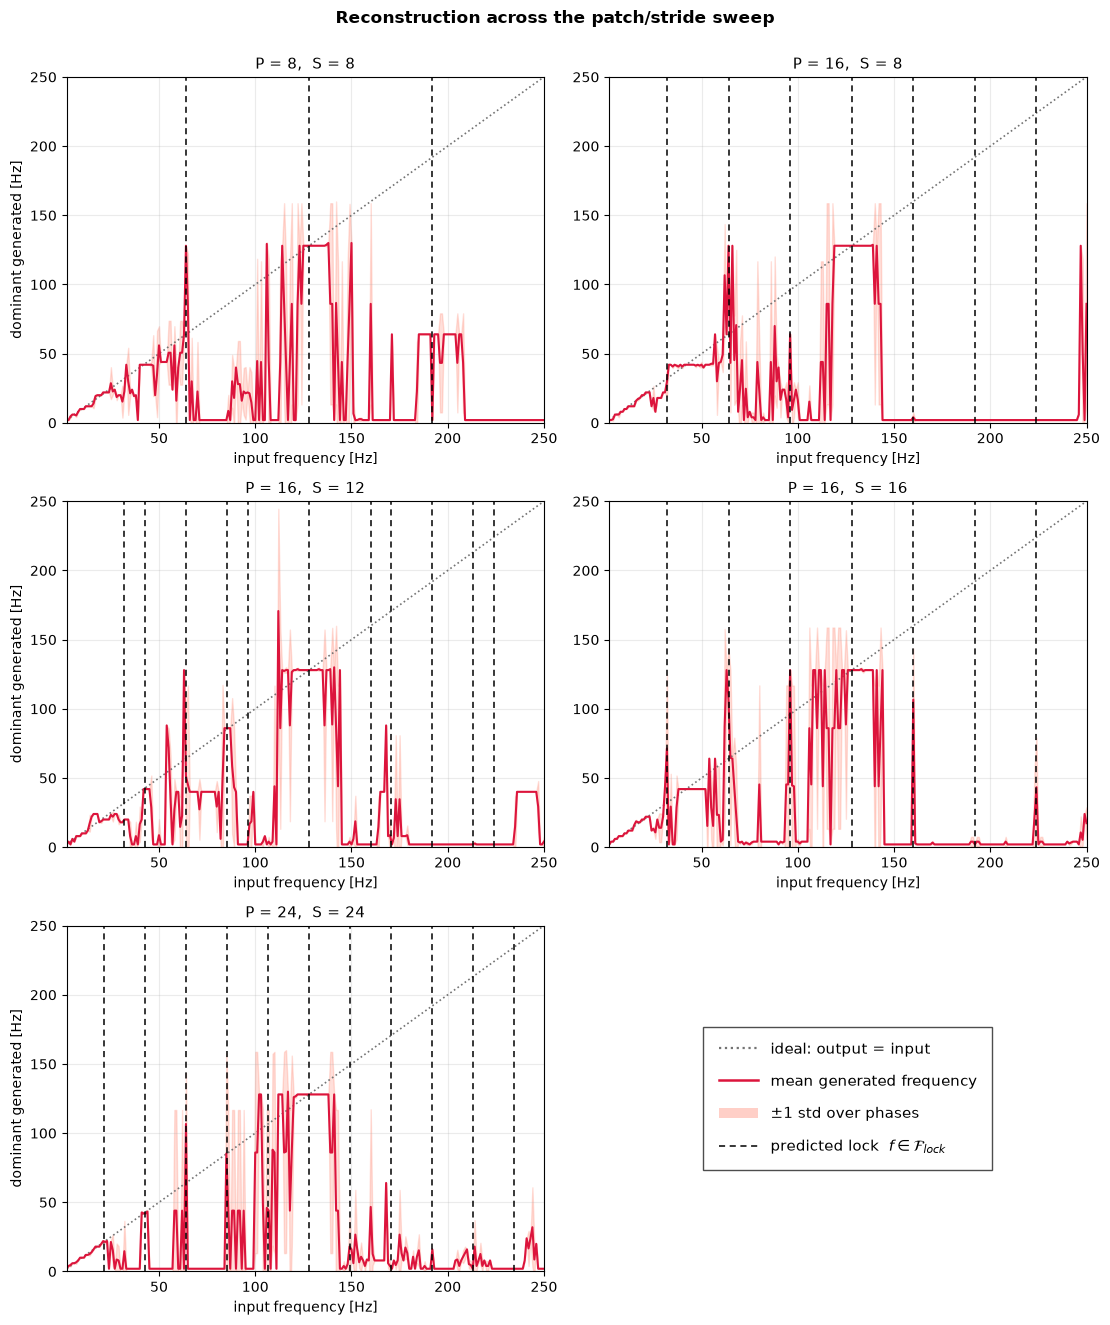

In [7]:
import math
tags_r = display_order(RESULTS)
ncols = 2
nrows = math.ceil(len(tags_r) / ncols)
fig, axgrid = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.4 * nrows),
                           sharex=True, sharey=True, squeeze=False)
flat = axgrid.ravel()
for ax, t in zip(flat, tags_r):
    r = RESULTS[t]; rc = r["recon"]
    ax.plot(pl.BAND, pl.BAND, ls=":", color="0.45", lw=1.2)
    ax.fill_between(rc["freq"], rc["mean"] - rc["std"].fillna(0), rc["mean"] + rc["std"].fillna(0),
                    color="tomato", alpha=.20)
    ax.plot(rc["freq"], rc["mean"], color="crimson", lw=1.5)
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.axvline(fk, color=C_LOCK, lw=1.1, ls=DASH_LOCK, alpha=1.0)
    ax.set_title(f"P = {r['P']},  S = {r['S']}", fontsize=11)
    ax.grid(alpha=.25)
    ax.tick_params(labelbottom=True, labelleft=True)
    ax.set_xlabel("input frequency [Hz]")
# With an odd number of geometries the grid leaves one slot empty: put the legend there rather
# than stealing height from the panels.
RECON_LEGEND = [
    Line2D([0], [0], ls=":", color="0.45", lw=1.6, label="ideal: output = input"),
    Line2D([0], [0], color="crimson", lw=1.8, label="mean generated frequency"),
    Patch(fc="tomato", alpha=.30, label="$\\pm$1 std over phases"),
    Line2D([0], [0], color=C_LOCK, lw=1.1, ls=DASH_LOCK,
           label="predicted lock  $f \\in \\mathcal{F}_{lock}$"),
]
spare = list(flat[len(tags_r):])
for ax in spare:
    ax.axis("off")
if spare:
    spare[0].legend(handles=RECON_LEGEND, loc="center", frameon=True, fancybox=False,
                    edgecolor="0.3", framealpha=1, fontsize=11,
                    handlelength=2.6, labelspacing=1.1, borderpad=1.0)
else:
    fig.legend(handles=RECON_LEGEND, loc="lower center", bbox_to_anchor=(0.5, -0.04),
               ncol=5, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
               fontsize=10, borderpad=0.7)
for row in axgrid:
    row[0].set_ylabel("dominant generated [Hz]")
flat[0].set_xlim(pl.BAND); flat[0].set_ylim(0, pl.BAND[1])
fig.suptitle("Reconstruction across the patch/stride sweep", fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(OUT / "FIG_ALL_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

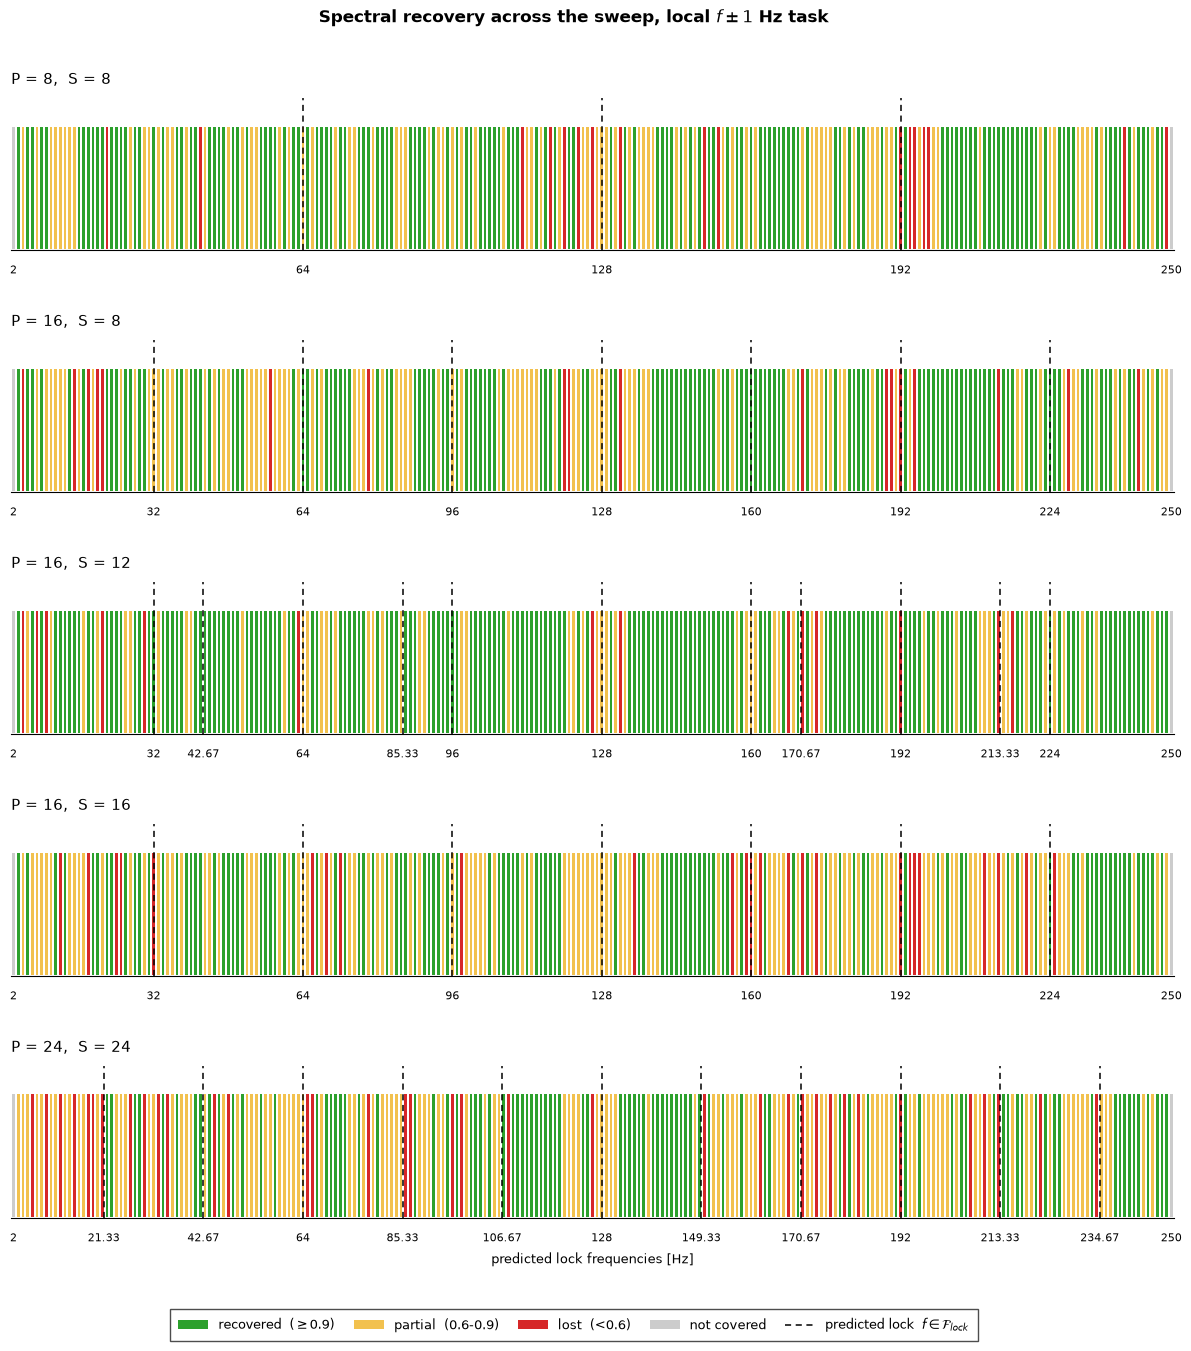

,model,P,S,spectral_RMSE_Hz,pct_on_diagonal,pct_recovered,pct_lost
0,p8-s8,8,8,127.1,13.3,57.4,6.8
1,p16-s8,16,8,132.8,12.9,55.8,7.2
2,p16-s12,16,12,128.7,11.6,70.3,5.6
3,p16-s16,16,16,132.6,13.3,45.4,10.0
4,p24-s24,24,24,131.0,12.9,38.2,14.5


In [8]:
# Five independent panels sharing one legend: each carries its own frequency axis, so a band can
# be read without tracing across to another panel's ticks.
tags = display_order(RESULTS)
fig, axes = plt.subplots(len(tags), 1, figsize=(15, 2.45 * len(tags) + 1.4), squeeze=False)
axes = axes[:, 0]
fig.subplots_adjust(hspace=0.95, top=0.90, bottom=0.10)

for ax, t in zip(axes, tags):
    r = RESULTS[t]
    ax.pcolormesh(np.arange(len(FREQS) + 1), np.array([0, 1]),
                  categorise(r["acc"][-1])[None, :],
                  cmap=CMAP, norm=NORM, edgecolors="white", linewidth=.25, zorder=2)
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.plot([xpos(fk)] * 2, [-LINE_OVER_BOT, 1 + LINE_OVER_TOP], color=C_LOCK, lw=1.1,
                ls=DASH_LOCK, zorder=4, clip_on=False)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"P = {r['P']},  S = {r['S']}", fontsize=11, pad=30, loc="left")
    label_lock_axis(ax, band_edges(own_locks(r["P"], r["S"])), xpos, fontsize=8)
    ax.tick_params(axis="x", length=0, pad=11)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

axes[-1].set_xlabel("predicted lock frequencies [Hz]",
                    fontsize=9.5, labelpad=6)
fig.suptitle("Spectral recovery across the sweep, local $f\pm1$ Hz task",
             fontweight="bold", y=0.985)
fig.legend(handles=LEGEND, loc="lower center", bbox_to_anchor=(0.5, 0.005),
           ncol=6, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
           fontsize=9, handlelength=2.4, columnspacing=1.5, borderpad=0.7)
fig.savefig(OUT / "FIG_ALL_spectral_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

summary = pd.DataFrame([
    dict(model=t,
         P=RESULTS[t]["P"], S=RESULTS[t]["S"],
         spectral_RMSE_Hz=round(float(np.sqrt(np.mean(
             (RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) ** 2))), 1),
         pct_on_diagonal=round(float(np.mean(
             np.abs(RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) <= 2.0)) * 100, 1),
         pct_recovered=round(float(np.nanmean(RESULTS[t]["acc"][-1] >= 0.9)) * 100, 1),
         pct_lost=round(float(np.nanmean(RESULTS[t]["acc"][-1] < 0.6)) * 100, 1))
    for t in display_order(RESULTS)])
summary.to_parquet(OUT.parent / "reconstruction_summary.parquet", index=False)
display(summary)

## How to read the two together

Figure 1 says what the model *outputs*; Figure 2 says what it still *knows*. They can disagree, and
each combination means something different:

* **on the diagonal and green**, the frequency is represented and rebuilt;
* **off the diagonal but green**, the information survives in the representation and is lost at the
  projection, which points at the head rather than at the tokenisation;
* **red**, the frequency is not recoverable from the representation at all, which is the stronger
  claim and the one structural aliasing predicts at the locked frequencies.

The dashed markers are the frequencies the geometry predicts as locked, $\mathcal{F}_{lock}$: the
union of the patch nulls $k f_s/P$ and the stride locks $c f_s/S$. On any $P=S$ geometry the two
families coincide, and only the $S<P$ configurations separate them.